In [1]:
from kafka import KafkaConsumer
import time
from torchvision import datasets, transforms
from PIL import Image
import shutil
import os
import random
import subprocess
import logging
from typing import Dict, Any, List, Tuple
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, accuracy_score
from datetime import datetime
import json
import matplotlib.pyplot as plt
from neo4j import GraphDatabase, Session
import networkx as nx
import uuid
logger = logging.getLogger(__name__)
__file__ = "training.ipynb"

KAFKA_BOOTSTRAP_SERVERS = "localhost:29092"
KAFKA_TOPICS = [
    "connector-output-topic",
    "line-detector-output-topic",
    "angle-point-detector-output-topic",
    "skeletonization-output-topic",
    "contour-analysis-output-topic",
    "classification-output-topic",
    "dlq-topic",
]
KAFKA_CONSUMER_TIMEOUT_MS = 1000
KAFKA_POLL_TIMEOUT_MS = 1000
CLASSIFICATION_TIMEOUT_SECS = 60
CONFUSION_MATRIX_FIGSIZE = (10, 7)
BINARIES_PATH = os.path.join(os.path.dirname(__file__), os.pardir, 'models', 'binaries')
TRAINING_RESULTS_DIR = "training_results"
uri = "bolt://localhost:7687"
user = "neo4j"
password = "111122223333"

In [2]:
def generate_mnist_samples(number: int, max_samples: int = 100, test_fraction: float = 0.2, output_dir: str = "../../tests/generated_samples", randomize: bool = True) -> None:
    """
    Generate and save MNIST samples for a specified number, split into train and test sets.

    Args:
        number (int): The MNIST digit to generate samples for (0-9).
        max_samples (int, optional): The maximum number of samples to generate. Defaults to 100.
        test_fraction (float, optional): Fraction of samples to use for test set. Defaults to 0.2.
        output_dir (str, optional): The base output directory. Defaults to "../../tests/generated_samples".

    Returns:
        None
    """
    # Set up the output directories
    digit_output_dir = os.path.join(output_dir, f"mnist_{number}")
    train_dir = os.path.join(digit_output_dir, "train")
    test_dir = os.path.join(digit_output_dir, "test")
    # Remove existing directories with files inside
    if os.path.exists(digit_output_dir):
        shutil.rmtree(digit_output_dir)
    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)

    # Download and load MNIST dataset
    transform = transforms.Compose([transforms.ToTensor()])
    mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

    # Filter for only the specified number
    filtered_dataset = [(img, label) for img, label in mnist_train if label == number]
    filtered_dataset = filtered_dataset[:max_samples] if not randomize else random.sample(filtered_dataset, min(max_samples, len(filtered_dataset)))
    
    # Calculate split indices
    test_size = int(len(filtered_dataset) * test_fraction)
    train_size = len(filtered_dataset) - test_size

    # Split dataset into train and test
    train_dataset = filtered_dataset[:train_size]
    test_dataset = filtered_dataset[train_size:]

    # Generate and save training images
    for i, (img, _) in enumerate(train_dataset):
        pil_img = transforms.ToPILImage()(img.squeeze())
        pil_img = pil_img.resize((100, 100), Image.BILINEAR)
        pil_img.save(os.path.join(train_dir, f"mnist_{number}_{i:05d}.png"))

    # Generate and save test images with separate counter
    for i, (img, _) in enumerate(test_dataset):
        pil_img = transforms.ToPILImage()(img.squeeze())
        pil_img = pil_img.resize((100, 100), Image.BILINEAR)
        pil_img.save(os.path.join(test_dir, f"mnist_{number}_{i:05d}.png"))

    print(f"Generated {train_size} training images and {test_size} test images of the number {number}")
    print(f"Training images in: {train_dir}")
    print(f"Test images in: {test_dir}")

In [3]:
class Neo4jToNetworkX:
    """Responsible for converting Neo4j graphs to NetworkX format"""

    @staticmethod
    def extract_composed_graph_of_class(session: Session, class_name: str) -> nx.Graph:
        query = """
        MATCH (n)
        WHERE n.session_id = $class_name AND (n:Point OR n:Vector)
        WITH n, labels(n) as node_labels, properties(n) as node_props
        OPTIONAL MATCH (n)-[r]-(m)
        WHERE m.session_id = $class_name AND (m:Point OR m:Vector)
        WITH n, node_labels, node_props, r, m
        RETURN elementId(n) as node_id,
               node_labels,
               node_props,
               type(r) as rel_type,
               elementId(m) as target_id
        """
        result = session.run(query, class_name=class_name)
        return Neo4jToNetworkX._build_networkx_graph(result)
    
    @staticmethod
    def extract_image_graph(session: Session, image_id: str) -> nx.Graph:
        """
        Extracts a graph from Neo4j for a given image_id and converts it to NetworkX format.
        This version excludes segment embedding (i.e. no Segment nodes or HAS_RELATIVE_POSITION edges).
        """
        query = """
        MATCH (n {image_id: $image_id})
        WHERE n:Point OR n:Vector
        WITH n, labels(n) as node_labels, properties(n) as node_props
        OPTIONAL MATCH (n)-[r]-(m {image_id: $image_id})
        WITH n, node_labels, r, m, node_props
        RETURN elementId(n) AS node_id, 
               node_labels,
               node_props,
               type(r) AS rel_type, 
               elementId(m) AS target_id
        """
        result = session.run(query, image_id=image_id)
        return Neo4jToNetworkX._build_networkx_graph(result)
    
    @staticmethod
    def _build_networkx_graph(result) -> nx.Graph:
        G = nx.Graph()
        nodes: Dict[int, Dict] = {}

        records = list(result)
        for record in records:
            node_id = record["node_id"]
            if node_id not in nodes:
                node_data = {
                    "labels": set(record["node_labels"]),
                    **record["node_props"]
                }
                nodes[node_id] = node_data

        for node_id, node_data in nodes.items():
            G.add_node(node_id, **node_data)

        for record in records:
            if record["target_id"] is not None:
                G.add_edge(
                    record["node_id"], record["target_id"], type=record["rel_type"]
                )

        return G

In [ ]:
with GraphDatabase.driver(uri, auth=(user, password)) as driver:
    with driver.session() as session:
        class_counts = {}
        for i in range(10):  # For digits 0-9
            graph = Neo4jToNetworkX.extract_composed_graph_of_class(session, str(i))
            class_counts[i] = nx.number_connected_components(graph)

        plt.figure(figsize=(10, 6))
        plt.bar(class_counts.keys(), class_counts.values())
        plt.xlabel('Digit Class')
        plt.ylabel('Number of Separate Graphs')
        plt.title('Number of Separate Graphs per Digit Class')
        plt.xticks(range(10))
        plt.show()


In [219]:

from torch_geometric.data import Data, Dataset
import networkx as nx
import torch
from neo4j import GraphDatabase

class MNISTGraphDataset(Dataset):
    def __init__(self, root: str, split: str = 'train', transform=None):
        super().__init__(root, transform)
        self.split = split
        self.data_list = []
        self.label_dict = {str(i): i for i in range(10)}  # MNIST has 10 classes
        self._process()
        
    def _process(self):
        """Process the composed graphs into individual graph samples"""
        with GraphDatabase.driver(uri, auth=(user, password)) as driver:
            with driver.session() as session:
                # Process each MNIST digit class (0-9)
                for digit in range(10):
                    # Get the composed graph containing all samples for this digit
                    composed_graph = Neo4jToNetworkX.extract_composed_graph_of_class(
                        session, 
                        str(digit)
                    )
                    
                    # Split into individual samples (each connected component is a sample)
                    for component in nx.connected_components(composed_graph):
                        # Extract the subgraph for this sample
                        sample_graph = composed_graph.subgraph(component).copy()
                        
                        # Convert to PyG Data object
                        data = MNISTGraphDataset.convert_to_pyg_data(sample_graph, digit)
                        self.data_list.append(data)
    
    @staticmethod
    def convert_to_pyg_data(graph: nx.Graph, label: int) -> Data:
        """Convert a NetworkX graph to PyTorch Geometric Data object"""
        # Visualize the graph
        # plt.figure(figsize=(10, 10))
        # pos = nx.spring_layout(graph)
        # nx.draw(graph, pos, node_size=100, node_color='lightblue', 
        #         with_labels=False, alpha=0.8)
        # plt.title(f'MNIST Graph Sample - Label: {label}')
        # plt.show()
        # Create node ID mapping (string -> int)
        node_mapping = {node: idx for idx, node in enumerate(graph.nodes())}
        
        # Extract node features
        node_features = MNISTGraphDataset._extract_node_features(graph)
        
        # Create edge index with integer IDs
        edge_list = [(node_mapping[src], node_mapping[dst]) for src, dst in graph.edges()]
        if edge_list:  # Check if graph has edges
            edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
        else:
            edge_index = torch.empty((2, 0), dtype=torch.long)
        
        # Create label tensor
        label_tensor = torch.tensor(label, dtype=torch.long)
        
        # Create PyG Data object
        data = Data(
            x=node_features,
            edge_index=edge_index,
            y=label_tensor
        )
        
        return data
    
    @staticmethod
    def _extract_node_features(graph: nx.Graph) -> torch.Tensor:
        """Extract node features from the graph"""
        features = []
        
        for node_id, node_data in graph.nodes(data=True):
            x = node_data.get('x', 0)
            y = node_data.get('y', 0)
            x1 = node_data.get('x1', 0)
            x2 = node_data.get('x2', 0)
            y1 = node_data.get('y1', 0)
            y2 = node_data.get('y2', 0)
            normalized_x = node_data.get('normalized_x', 0) # normalized x coordinate to the center of the image
            normalized_y = node_data.get('normalized_y', 0) # normalized y coordinate to the center of the image
            relative_distance = node_data.get('relative_distance', 0) # relative distance to the center of the image
            
            # Compute the quadrant relative to the center of the coordinate space
            if normalized_x >= 0 and normalized_y >= 0:
                quadrant = 1  # Quadrant I: top-right
            elif normalized_x < 0 and normalized_y >= 0:
                quadrant = 2  # Quadrant II: top-left
            elif normalized_x < 0 and normalized_y < 0:
                quadrant = 3  # Quadrant III: bottom-left
            else:  # normalized_x >= 0 and normalized_y < 0:
                quadrant = 4  # Quadrant IV: bottom-right

            # Node type features
            is_point = 1.0 if "Point" in node_data.get('labels', []) else 0.0
            is_endpoint = 1.0 if "Endpoint" in node_data.get('labels', []) else 0.0
            is_intersection_point = 1.0 if "IntersectionPoint" in node_data.get('labels', []) else 0.0
            is_corner_point = 1.0 if "CornerPoint" in node_data.get('labels', []) else 0.0
            is_vector = 1.0 if "Vector" in node_data.get('labels', []) else 0.0
            is_vertical_vector = 1.0 if "VerticalVector" in node_data.get('labels', []) else 0.0
            is_horizontal_vector = 1.0 if "HorizontalVector" in node_data.get('labels', []) else 0.0
            angle = node_data.get('angle', 0)
            angle_with_ox = node_data.get('angle_with_ox', 0)
            half_plane = 0 # TODO: add this
            # quadrant = node_data.get('quadrant', 0)
            length = node_data.get('length', 0)
            length1 = node_data.get('length1', 0)
            length2 = node_data.get('length2', 0)
            
            corner_points_count = node_data.get('corner_points_count', 0)
            endpoints_count = node_data.get('endpoints_count', 0)
            intersection_points_count = node_data.get('intersection_points_count', 0)
            quadrant_change_count = node_data.get('quadrant_change_count', 0)
            vectors_count = node_data.get('vectors_count', 0)
            
            is_quadrant_change = node_data.get('is_quadrant_change', 0)
            
            monotony_result = node_data.get('monotony', 0)
            is_monotony = 1.0 if monotony_result == 'MONOTONIC' else 0.0
            
            contour_type_result = node_data.get('contour_type', 0)
            is_closed = 1.0 if contour_type_result == 'Closed' else 0.0
            
            num_cycles = node_data.get('cycle_count', 0)
            
            # Structural features
            degree = graph.degree(node_id) / 10.0  # Normalize degree
            
            # Combine features
            node_features = [
                x, y, x1, y1, x2, y2,
                quadrant,
                normalized_x, normalized_y, relative_distance,
                is_point, is_vector,
                is_endpoint, is_intersection_point, is_corner_point,
                is_vertical_vector, is_horizontal_vector,
                degree, angle, angle_with_ox, half_plane, quadrant, length, length1, length2,
                corner_points_count, endpoints_count, intersection_points_count, quadrant_change_count, is_quadrant_change, vectors_count,
                is_monotony, is_closed, num_cycles
            ]
            features.append(node_features)
        
        return torch.tensor(features, dtype=torch.float)
    
    def len(self) -> int:
        return len(self.data_list)
    
    def get(self, idx: int) -> Data:
        return self.data_list[idx]

In [220]:
import torch.nn as nn
from torch.optim import Adam

class GAT(torch.nn.Module):
    """
    The most interesting and hardest implementation is implementation #3.
    Imp1 and imp2 differ in subtle details but are basically the same thing.

    So I'll focus on imp #3 in this notebook.

    """

    def __init__(self, num_of_layers, num_heads_per_layer, num_features_per_layer, add_skip_connection=True, bias=True,
                 dropout=0.6, log_attention_weights=False):
        super().__init__()
        assert num_of_layers == len(num_heads_per_layer) == len(num_features_per_layer) - 1, f'Enter valid arch params.'
        
        print(f"GAT initialized with {num_of_layers} layers, {num_heads_per_layer} heads per layer, {num_features_per_layer} features per layer")
        print(f"Dropout: {dropout}")
        print(f"Add skip connection: {add_skip_connection}")
        print(f"Bias: {bias}")
        print(f"Log attention weights: {log_attention_weights}")

        num_heads_per_layer = [1] + num_heads_per_layer  # trick - so that I can nicely create GAT layers below

        gat_layers = []  # collect GAT layers
        for i in range(num_of_layers):
            layer = GATLayer(
                num_in_features=num_features_per_layer[i] * num_heads_per_layer[i],  # consequence of concatenation
                num_out_features=num_features_per_layer[i+1],
                num_of_heads=num_heads_per_layer[i+1],
                concat=True if i < num_of_layers - 1 else False,  # last GAT layer does mean avg, the others do concat
                activation=nn.ELU() if i < num_of_layers - 1 else None,  # last layer just outputs raw scores
                dropout_prob=dropout,
                add_skip_connection=add_skip_connection,
                bias=bias,
                log_attention_weights=log_attention_weights
            )
            gat_layers.append(layer)

        self.gat_net = nn.Sequential(
            *gat_layers,
        )

    # data is just a (in_nodes_features, edge_index) tuple, I had to do it like this because of the nn.Sequential:
    # https://discuss.pytorch.org/t/forward-takes-2-positional-arguments-but-3-were-given-for-nn-sqeuential-with-linear-layers/65698
    def forward(self, data):
        return self.gat_net(data)

In [221]:
class GATLayer(torch.nn.Module):
    """
    Implementation #3 was inspired by PyTorch Geometric: https://github.com/rusty1s/pytorch_geometric

    But, it's hopefully much more readable! (and of similar performance)

    """
    
    # We'll use these constants in many functions so just extracting them here as member fields
    src_nodes_dim = 0  # position of source nodes in edge index
    trg_nodes_dim = 1  # position of target nodes in edge index

    # These may change in the inductive setting - leaving it like this for now (not future proof)
    nodes_dim = 0      # node dimension (axis is maybe a more familiar term nodes_dim is the position of "N" in tensor)
    head_dim = 1       # attention head dim

    def __init__(self, num_in_features, num_out_features, num_of_heads, concat=True, activation=nn.ELU(),
                 dropout_prob=0.6, add_skip_connection=True, bias=True, log_attention_weights=False):

        super().__init__()

        self.num_of_heads = num_of_heads
        self.num_out_features = num_out_features
        self.concat = concat  # whether we should concatenate or average the attention heads
        self.add_skip_connection = add_skip_connection

        #
        # Trainable weights: linear projection matrix (denoted as "W" in the paper), attention target/source
        # (denoted as "a" in the paper) and bias (not mentioned in the paper but present in the official GAT repo)
        #

        # You can treat this one matrix as num_of_heads independent W matrices
        self.linear_proj = nn.Linear(num_in_features, num_of_heads * num_out_features, bias=False)

        # After we concatenate target node (node i) and source node (node j) we apply the "additive" scoring function
        # which gives us un-normalized score "e". Here we split the "a" vector - but the semantics remain the same.
        # Basically instead of doing [x, y] (concatenation, x/y are node feature vectors) and dot product with "a"
        # we instead do a dot product between x and "a_left" and y and "a_right" and we sum them up
        self.scoring_fn_target = nn.Parameter(torch.Tensor(1, num_of_heads, num_out_features))
        self.scoring_fn_source = nn.Parameter(torch.Tensor(1, num_of_heads, num_out_features))

        # Bias is definitely not crucial to GAT - feel free to experiment (I pinged the main author, Petar, on this one)
        if bias and concat:
            self.bias = nn.Parameter(torch.Tensor(num_of_heads * num_out_features))
        elif bias and not concat:
            self.bias = nn.Parameter(torch.Tensor(num_out_features))
        else:
            self.register_parameter('bias', None)

        if add_skip_connection:
            self.skip_proj = nn.Linear(num_in_features, num_of_heads * num_out_features, bias=False)
        else:
            self.register_parameter('skip_proj', None)

        #
        # End of trainable weights
        #

        self.leakyReLU = nn.LeakyReLU(0.2)  # using 0.2 as in the paper, no need to expose every setting
        self.activation = activation
        # Probably not the nicest design but I use the same module in 3 locations, before/after features projection
        # and for attention coefficients. Functionality-wise it's the same as using independent modules.
        self.dropout = nn.Dropout(p=dropout_prob)

        self.log_attention_weights = log_attention_weights  # whether we should log the attention weights
        self.attention_weights = None  # for later visualization purposes, I cache the weights here

        self.init_params()
        
    def forward(self, data):
        #
        # Step 1: Linear Projection + regularization
        #

        in_nodes_features, edge_index = data  # unpack data
        num_of_nodes = in_nodes_features.shape[self.nodes_dim]
        assert edge_index.shape[0] == 2, f'Expected edge index with shape=(2,E) got {edge_index.shape}'

        # shape = (N, FIN) where N - number of nodes in the graph, FIN - number of input features per node
        # We apply the dropout to all of the input node features (as mentioned in the paper)
        in_nodes_features = self.dropout(in_nodes_features)

        # shape = (N, FIN) * (FIN, NH*FOUT) -> (N, NH, FOUT) where NH - number of heads, FOUT - num of output features
        # We project the input node features into NH independent output features (one for each attention head)
        nodes_features_proj = self.linear_proj(in_nodes_features).view(-1, self.num_of_heads, self.num_out_features)

        nodes_features_proj = self.dropout(nodes_features_proj)  # in the official GAT imp they did dropout here as well

        #
        # Step 2: Edge attention calculation
        #

        # Apply the scoring function (* represents element-wise (a.k.a. Hadamard) product)
        # shape = (N, NH, FOUT) * (1, NH, FOUT) -> (N, NH, 1) -> (N, NH) because sum squeezes the last dimension
        # Optimization note: torch.sum() is as performant as .sum() in my experiments
        scores_source = (nodes_features_proj * self.scoring_fn_source).sum(dim=-1)
        scores_target = (nodes_features_proj * self.scoring_fn_target).sum(dim=-1)

        # We simply copy (lift) the scores for source/target nodes based on the edge index. Instead of preparing all
        # the possible combinations of scores we just prepare those that will actually be used and those are defined
        # by the edge index.
        # scores shape = (E, NH), nodes_features_proj_lifted shape = (E, NH, FOUT), E - number of edges in the graph
        scores_source_lifted, scores_target_lifted, nodes_features_proj_lifted = self.lift(scores_source, scores_target, nodes_features_proj, edge_index)
        scores_per_edge = self.leakyReLU(scores_source_lifted + scores_target_lifted)

        # shape = (E, NH, 1)
        attentions_per_edge = self.neighborhood_aware_softmax(scores_per_edge, edge_index[self.trg_nodes_dim], num_of_nodes)
        # Add stochasticity to neighborhood aggregation
        attentions_per_edge = self.dropout(attentions_per_edge)

        #
        # Step 3: Neighborhood aggregation
        #

        # Element-wise (aka Hadamard) product. Operator * does the same thing as torch.mul
        # shape = (E, NH, FOUT) * (E, NH, 1) -> (E, NH, FOUT), 1 gets broadcast into FOUT
        nodes_features_proj_lifted_weighted = nodes_features_proj_lifted * attentions_per_edge

        # This part sums up weighted and projected neighborhood feature vectors for every target node
        # shape = (N, NH, FOUT)
        out_nodes_features = self.aggregate_neighbors(nodes_features_proj_lifted_weighted, edge_index, in_nodes_features, num_of_nodes)

        #
        # Step 4: Residual/skip connections, concat and bias
        #

        out_nodes_features = self.skip_concat_bias(attentions_per_edge, in_nodes_features, out_nodes_features)
        return (out_nodes_features, edge_index)

    #
    # Helper functions (without comments there is very little code so don't be scared!)
    #

    def neighborhood_aware_softmax(self, scores_per_edge, trg_index, num_of_nodes):
        """
        As the fn name suggest it does softmax over the neighborhoods. Example: say we have 5 nodes in a graph.
        Two of them 1, 2 are connected to node 3. If we want to calculate the representation for node 3 we should take
        into account feature vectors of 1, 2 and 3 itself. Since we have scores for edges 1-3, 2-3 and 3-3
        in scores_per_edge variable, this function will calculate attention scores like this: 1-3/(1-3+2-3+3-3)
        (where 1-3 is overloaded notation it represents the edge 1-3 and its (exp) score) and similarly for 2-3 and 3-3
         i.e. for this neighborhood we don't care about other edge scores that include nodes 4 and 5.

        Note:
        Subtracting the max value from logits doesn't change the end result but it improves the numerical stability
        and it's a fairly common "trick" used in pretty much every deep learning framework.
        Check out this link for more details:

        https://stats.stackexchange.com/questions/338285/how-does-the-subtraction-of-the-logit-maximum-improve-learning

        """
        # Calculate the numerator. Make logits <= 0 so that e^logit <= 1 (this will improve the numerical stability)
        scores_per_edge = scores_per_edge - scores_per_edge.max()
        exp_scores_per_edge = scores_per_edge.exp()  # softmax

        # Calculate the denominator. shape = (E, NH)
        neigborhood_aware_denominator = self.sum_edge_scores_neighborhood_aware(exp_scores_per_edge, trg_index, num_of_nodes)

        # 1e-16 is theoretically not needed but is only there for numerical stability (avoid div by 0) - due to the
        # possibility of the computer rounding a very small number all the way to 0.
        attentions_per_edge = exp_scores_per_edge / (neigborhood_aware_denominator + 1e-16)

        # shape = (E, NH) -> (E, NH, 1) so that we can do element-wise multiplication with projected node features
        return attentions_per_edge.unsqueeze(-1)

    def sum_edge_scores_neighborhood_aware(self, exp_scores_per_edge, trg_index, num_of_nodes):
        # The shape must be the same as in exp_scores_per_edge (required by scatter_add_) i.e. from E -> (E, NH)
        trg_index_broadcasted = self.explicit_broadcast(trg_index, exp_scores_per_edge)

        # shape = (N, NH), where N is the number of nodes and NH the number of attention heads
        size = list(exp_scores_per_edge.shape)  # convert to list otherwise assignment is not possible
        size[self.nodes_dim] = num_of_nodes
        neighborhood_sums = torch.zeros(size, dtype=exp_scores_per_edge.dtype, device=exp_scores_per_edge.device)

        # position i will contain a sum of exp scores of all the nodes that point to the node i (as dictated by the
        # target index)
        neighborhood_sums.scatter_add_(self.nodes_dim, trg_index_broadcasted, exp_scores_per_edge)

        # Expand again so that we can use it as a softmax denominator. e.g. node i's sum will be copied to
        # all the locations where the source nodes pointed to i (as dictated by the target index)
        # shape = (N, NH) -> (E, NH)
        return neighborhood_sums.index_select(self.nodes_dim, trg_index)

    def aggregate_neighbors(self, nodes_features_proj_lifted_weighted, edge_index, in_nodes_features, num_of_nodes):
        size = list(nodes_features_proj_lifted_weighted.shape)  # convert to list otherwise assignment is not possible
        size[self.nodes_dim] = num_of_nodes  # shape = (N, NH, FOUT)
        out_nodes_features = torch.zeros(size, dtype=in_nodes_features.dtype, device=in_nodes_features.device)

        # shape = (E) -> (E, NH, FOUT)
        trg_index_broadcasted = self.explicit_broadcast(edge_index[self.trg_nodes_dim], nodes_features_proj_lifted_weighted)
        # aggregation step - we accumulate projected, weighted node features for all the attention heads
        # shape = (E, NH, FOUT) -> (N, NH, FOUT)
        out_nodes_features.scatter_add_(self.nodes_dim, trg_index_broadcasted, nodes_features_proj_lifted_weighted)

        return out_nodes_features

    def lift(self, scores_source, scores_target, nodes_features_matrix_proj, edge_index):
        """
        Lifts i.e. duplicates certain vectors depending on the edge index.
        One of the tensor dims goes from N -> E (that's where the "lift" comes from).

        """
        src_nodes_index = edge_index[self.src_nodes_dim]
        trg_nodes_index = edge_index[self.trg_nodes_dim]

        # Using index_select is faster than "normal" indexing (scores_source[src_nodes_index]) in PyTorch!
        scores_source = scores_source.index_select(self.nodes_dim, src_nodes_index)
        scores_target = scores_target.index_select(self.nodes_dim, trg_nodes_index)
        nodes_features_matrix_proj_lifted = nodes_features_matrix_proj.index_select(self.nodes_dim, src_nodes_index)

        return scores_source, scores_target, nodes_features_matrix_proj_lifted

    def explicit_broadcast(self, this, other):
        # Append singleton dimensions until this.dim() == other.dim()
        for _ in range(this.dim(), other.dim()):
            this = this.unsqueeze(-1)

        # Explicitly expand so that shapes are the same
        return this.expand_as(other)

    def init_params(self):
        """
        The reason we're using Glorot (aka Xavier uniform) initialization is because it's a default TF initialization:
            https://stackoverflow.com/questions/37350131/what-is-the-default-variable-initializer-in-tensorflow

        The original repo was developed in TensorFlow (TF) and they used the default initialization.
        Feel free to experiment - there may be better initializations depending on your problem.

        """
        nn.init.xavier_uniform_(self.linear_proj.weight)
        nn.init.xavier_uniform_(self.scoring_fn_target)
        nn.init.xavier_uniform_(self.scoring_fn_source)

        if self.bias is not None:
            torch.nn.init.zeros_(self.bias)

    def skip_concat_bias(self, attention_coefficients, in_nodes_features, out_nodes_features):
        if self.log_attention_weights:  # potentially log for later visualization in playground.py
            self.attention_weights = attention_coefficients

        if self.add_skip_connection:  # add skip or residual connection
            if out_nodes_features.shape[-1] == in_nodes_features.shape[-1]:  # if FIN == FOUT
                # unsqueeze does this: (N, FIN) -> (N, 1, FIN), out features are (N, NH, FOUT) so 1 gets broadcast to NH
                # thus we're basically copying input vectors NH times and adding to processed vectors
                out_nodes_features += in_nodes_features.unsqueeze(1)
            else:
                # FIN != FOUT so we need to project input feature vectors into dimension that can be added to output
                # feature vectors. skip_proj adds lots of additional capacity which may cause overfitting.
                out_nodes_features += self.skip_proj(in_nodes_features).view(-1, self.num_of_heads, self.num_out_features)

        if self.concat:
            # shape = (N, NH, FOUT) -> (N, NH*FOUT)
            out_nodes_features = out_nodes_features.view(-1, self.num_of_heads * self.num_out_features)
        else:
            # shape = (N, NH, FOUT) -> (N, FOUT)
            out_nodes_features = out_nodes_features.mean(dim=self.head_dim)

        if self.bias is not None:
            out_nodes_features += self.bias

        return out_nodes_features if self.activation is None else self.activation(out_nodes_features)

In [222]:
from torch.utils.tensorboard import SummaryWriter
import enum


# 3 different model training/eval phases used in train.py
class LoopPhase(enum.Enum):
    TRAIN = 0,
    VAL = 1,
    TEST = 2

    
writer = SummaryWriter()  # (tensorboard) writer will output to ./runs/ directory by default


# Global vars used for early stopping. After some number of epochs (as defined by the patience_period var) without any
# improvement on the validation dataset (measured via micro-F1 metric), we'll break out from the training loop.
BEST_VAL_MICRO_F1 = 0
BEST_VAL_LOSS = 0
PATIENCE_CNT = 0

BINARIES_PATH = os.path.join(os.getcwd(), 'models', 'binaries')
CHECKPOINTS_PATH = os.path.join(os.getcwd(), 'models', 'checkpoints')

# Make sure these exist as the rest of the code assumes it
os.makedirs(BINARIES_PATH, exist_ok=True)
os.makedirs(CHECKPOINTS_PATH, exist_ok=True)

In [223]:
import re  # regex


def get_training_state(training_config, model):
    training_state = {
        # "commit_hash": git.Repo(search_parent_directories=True).head.object.hexsha,

        # Training details
        "dataset_name": training_config['dataset_name'],
        "num_of_epochs": training_config['num_of_epochs'],
        "test_perf": training_config['test_perf'],

        # Model structure
        "num_of_layers": training_config['num_of_layers'],
        "num_heads_per_layer": training_config['num_heads_per_layer'],
        "num_features_per_layer": training_config['num_features_per_layer'],
        "add_skip_connection": training_config['add_skip_connection'],
        "bias": training_config['bias'],
        "dropout": training_config['dropout'],
        "layer_type": training_config['layer_type'],

        # Model state
        "state_dict": model.state_dict()
    }

    return training_state


def print_model_metadata(training_state):
    header = f'\n{"*"*5} Model training metadata: {"*"*5}'
    print(header)

    for key, value in training_state.items():
        if key != 'state_dict':  # don't print state_dict it's a bunch of numbers...
            print(f'{key}: {value}')
    print(f'{"*" * len(header)}\n')
    

# This one makes sure we don't overwrite the valuable model binaries (feel free to ignore - not crucial to GAT method)
def get_available_binary_name(dataset_name='unknown'):
    prefix = f'gat_{dataset_name}'

    def valid_binary_name(binary_name):
        # First time you see raw f-string? Don't worry the only trick is to double the brackets.
        pattern = re.compile(rf'{prefix}_[0-9]{{6}}\.pth')
        return re.fullmatch(pattern, binary_name) is not None

    # Just list the existing binaries so that we don't overwrite them but write to a new one
    valid_binary_names = list(filter(valid_binary_name, os.listdir(BINARIES_PATH)))
    if len(valid_binary_names) > 0:
        last_binary_name = sorted(valid_binary_names)[-1]
        new_suffix = int(last_binary_name.split('.')[0][-6:]) + 1  # increment by 1
        return f'{prefix}_{str(new_suffix).zfill(6)}.pth'
    else:
        return f'{prefix}_000000.pth'

In [312]:
import argparse
import time
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.nn.functional import cross_entropy
from sklearn.metrics import accuracy_score
from torch_geometric.data import DataLoader
from torch_geometric.nn import global_mean_pool
import enum
from collections import Counter
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support


def get_main_loop(config, gat, cross_entropy_loss, optimizer, patience_period, time_start):
    device = next(gat.parameters()).device
    results_dir = os.path.join(CHECKPOINTS_PATH, 'results')
    os.makedirs(results_dir, exist_ok=True)

    def main_loop(phase, data_loader, epoch=0):
        global BEST_VAL_PERF, BEST_VAL_LOSS, PATIENCE_CNT

        if phase == LoopPhase.TRAIN:
            gat.train()
        else:
            gat.eval()

        total_loss = 0
        all_preds = []
        all_labels = []

        for batch in data_loader:
            batch = batch.to(device)
            node_features = batch.x
            labels = batch.y
            edge_index = batch.edge_index
            graph_idx = batch.batch

            logits = gat((node_features, edge_index))[0]
            graph_embeddings = global_mean_pool(logits, graph_idx)
            
            # Calculate loss
            loss = cross_entropy_loss(graph_embeddings, labels)

            if phase == LoopPhase.TRAIN:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item()

            # Get predictions
            preds = torch.argmax(graph_embeddings, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Logging
            global_step = len(data_loader) * epoch
            
            if phase == LoopPhase.TRAIN:
                if config['enable_tensorboard']:
                    writer.add_scalar('training_loss', loss.item(), global_step)
                
                if config['console_log_freq']:
                    batch_accuracy = accuracy_score(all_labels, all_preds)
                    print(f'GAT training: time elapsed= {(time.time() - time_start):.2f} [s] |'
                          f' epoch={epoch + 1} | batch accuracy={batch_accuracy:.4f}')

            elif phase == LoopPhase.VAL:
                accuracy = accuracy_score(all_labels, all_preds)
                print(f'accuracy: {accuracy}, best val: {BEST_VAL_PERF}')
                
                if accuracy > BEST_VAL_PERF or loss.item() < BEST_VAL_LOSS:
                    BEST_VAL_PERF = max(accuracy, BEST_VAL_PERF)
                    BEST_VAL_LOSS = min(loss.item(), BEST_VAL_LOSS)
                    PATIENCE_CNT = 0
                else:
                    PATIENCE_CNT += 1

                if PATIENCE_CNT >= patience_period:
                    raise Exception('Stopping the training, patience exceeded.')

        # For test phase, calculate metrics after all batches
        if phase == LoopPhase.TEST:
            # Calculate final metrics on complete test set
            accuracy = accuracy_score(all_labels, all_preds)
            cm = confusion_matrix(all_labels, all_preds)
            precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average=None)
            
            # Create timestamp for unique filenames
            timestamp = time.strftime("%Y%m%d_%H%M%S")
            
            # Save confusion matrix visualization
            plt.figure(figsize=(12, 8))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
            plt.title(f'Confusion Matrix (Test Accuracy: {accuracy:.4f})')
            plt.ylabel('True Label')
            plt.xlabel('Predicted Label')
            
            # Save confusion matrix plot
            cm_path = os.path.join(results_dir, f'confusion_matrix_{timestamp}.png')
            plt.savefig(cm_path, dpi=300, bbox_inches='tight')
            plt.close()
            
            # Save metrics to a text file
            metrics_path = os.path.join(results_dir, f'test_metrics_{timestamp}.txt')
            with open(metrics_path, 'w') as f:
                f.write(f"Test Results ({timestamp})\n")
                f.write("=" * 50 + "\n\n")
                f.write(f"Overall Accuracy: {accuracy:.4f}\n\n")
                f.write("Per-class Metrics:\n")
                f.write("-" * 30 + "\n")
                for i in range(len(precision)):
                    f.write(f"\nClass {i}:\n")
                    f.write(f"Precision: {precision[i]:.4f}\n")
                    f.write(f"Recall: {recall[i]:.4f}\n")
                    f.write(f"F1-score: {f1[i]:.4f}\n")
            
            print(f"\nResults saved to:")
            print(f"- Confusion Matrix: {cm_path}")
            print(f"- Metrics: {metrics_path}")
            
            return accuracy

        return None

    return main_loop

def train_gat_mnist(config):
    global train_dataset, val_dataset, test_dataset, model
    
    device = torch.device("cuda" if torch.cuda.is_available() and not config['force_cpu'] else "cpu")

    # Create dataset and dataloaders
    dataset = MNISTGraphDataset(root='data/mnist_graphs')
    
    # Split dataset
    train_size = int(0.7 * len(dataset))
    # train_size = 200
    val_size = int(0.1 * len(dataset))
    test_size = len(dataset) - train_size - val_size
    print("Train size: ", train_size)
    print("Val size: ", val_size)
    print("Test size: ", test_size)
    
    train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
        dataset, [train_size, val_size, test_size]
    )
    
    # Calculate label distributions
    def get_label_distribution(dataset_split):
        labels = [data.y.item() for data in dataset_split]
        return Counter(labels)
    
    trainset_label_distribution = get_label_distribution(train_dataset)
    valset_label_distribution = get_label_distribution(val_dataset) 
    testset_label_distribution = get_label_distribution(test_dataset)
    
    print("Trainset label distribution: ", trainset_label_distribution)
    print("Valset label distribution: ", valset_label_distribution)
    print("Testset label distribution: ", testset_label_distribution)
    
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config['batch_size'])
    test_loader = DataLoader(test_dataset, batch_size=config['batch_size'])

    # Initialize model
    gat = GAT(
        num_of_layers=config['num_of_layers'],
        num_heads_per_layer=config['num_heads_per_layer'],
        num_features_per_layer=config['num_features_per_layer'],
        add_skip_connection=config['add_skip_connection'],
        bias=config['bias'],
        dropout=config['dropout'],
        log_attention_weights=True
    ).to(device)
    model = gat

    # Loss and optimizer
    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(gat.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])

    # Training loop
    main_loop = get_main_loop(config, gat, loss_fn, optimizer, config['patience_period'], time.time())

    global BEST_VAL_PERF, BEST_VAL_LOSS, PATIENCE_CNT
    BEST_VAL_PERF, BEST_VAL_LOSS, PATIENCE_CNT = [0, float('inf'), 0]

    for epoch in range(config['num_of_epochs']):
        main_loop(phase=LoopPhase.TRAIN, data_loader=train_loader, epoch=epoch)

        with torch.no_grad():
            try:
                main_loop(phase=LoopPhase.VAL, data_loader=val_loader, epoch=epoch)
            except Exception as e:
                print(str(e))
                break

    if config['should_test']:
        accuracy = main_loop(phase=LoopPhase.TEST, data_loader=test_loader)
        config['test_perf'] = accuracy
        print(f'Test accuracy = {accuracy:.4f}')

    # Save model
    torch.save(
        get_training_state(config, gat),
        os.path.join(BINARIES_PATH, f'gat_mnist_{time.strftime("%Y%m%d_%H%M%S")}.pth')
    )



def get_training_args():
    """Get training arguments while ignoring Jupyter's additional args"""
    import sys
    
    # Store original args
    original_args = sys.argv[:]
    
    # Remove Jupyter's arguments (they start with '--f')
    sys.argv = [arg for arg in sys.argv if not arg.startswith('--f')]
    
    parser = argparse.ArgumentParser()
    
    # Training parameters
    parser.add_argument("--num_of_epochs", type=int, default=1000)
    parser.add_argument("--patience_period", type=int, default=20)
    parser.add_argument("--lr", type=float, default=0.001)
    parser.add_argument("--weight_decay", type=float, default=1e-4)
    parser.add_argument("--batch_size", type=int, default=64)
    
    try:
        args = parser.parse_args()
    except:
        # If parsing fails, use default values
        args = parser.parse_args([])
    
    # Restore original args
    sys.argv = original_args
    
    # Model parameters
    gat_config = {
        "num_of_layers": 3,
        "num_heads_per_layer": [8, 8, 1],  # Last layer has 1 head for classification
        "num_features_per_layer": [34, 64, 64, 10], # [input_features, hidden, hidden, num_classes]
        "add_skip_connection": True,
        "bias": True,
        "dropout": 0.1,
        "enable_tensorboard": True,
        "console_log_freq": 10,
        "should_test": True,
        "dataset_name": "mnist",
        "layer_type": "imp3"
    }
    
    config = vars(args)
    config.update(gat_config)
    
    return config

In [290]:
def visualize_dataset_embeddings(dataset, writer):
    """
    Visualize the feature vectors of the dataset using TensorBoard.
    
    Args:
        dataset: MNISTGraphDataset instance
        writer: SummaryWriter instance
    """
    # Collect features and labels
    all_features = []
    all_labels = []
    
    for data in dataset:
        # Get node features and take mean across nodes to get graph-level features
        node_features = data.x
        graph_features = node_features.mean(dim=0)  # Average node features
        all_features.append(graph_features)
        all_labels.append(str(data.y.item()))  # Convert labels to strings
    
    # Stack all features into a single tensor
    features = torch.stack(all_features)
    
    # Log embeddings to TensorBoard
    writer.add_embedding(
        features,
        metadata=all_labels,
        global_step=0,
        tag='graph_features'
    )
    writer.close()

# Usage example:
writer = SummaryWriter('runs/feature_visualization')
dataset = MNISTGraphDataset(root='data/mnist_graphs')
visualize_dataset_embeddings(dataset, writer)

print("Run 'tensorboard --logdir=runs' in terminal and open http://localhost:6006")

Run 'tensorboard --logdir=runs' in terminal and open http://localhost:6006


In [313]:
train_gat_mnist(get_training_args())

Train size:  1120
Val size:  160
Test size:  320
Trainset label distribution:  Counter({0: 119, 8: 117, 1: 115, 3: 113, 6: 110, 4: 110, 9: 109, 2: 109, 7: 109, 5: 109})
Valset label distribution:  Counter({2: 21, 7: 20, 4: 19, 8: 18, 5: 16, 0: 15, 1: 15, 9: 14, 6: 13, 3: 9})
Testset label distribution:  Counter({3: 38, 6: 37, 9: 37, 5: 35, 7: 31, 4: 31, 1: 30, 2: 30, 0: 26, 8: 25})
GAT initialized with 3 layers, [8, 8, 1] heads per layer, [34, 64, 64, 10] features per layer
Dropout: 0.1
Add skip connection: True
Bias: True
Log attention weights: True
GAT training: time elapsed= 0.04 [s] | epoch=1 | batch accuracy=0.0781
GAT training: time elapsed= 0.10 [s] | epoch=1 | batch accuracy=0.0859
GAT training: time elapsed= 0.15 [s] | epoch=1 | batch accuracy=0.1042


/Users/mlapin/anaconda3/envs/natural_agi/lib/python3.11/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


GAT training: time elapsed= 0.22 [s] | epoch=1 | batch accuracy=0.1094
GAT training: time elapsed= 0.27 [s] | epoch=1 | batch accuracy=0.1406
GAT training: time elapsed= 0.32 [s] | epoch=1 | batch accuracy=0.1615
GAT training: time elapsed= 0.38 [s] | epoch=1 | batch accuracy=0.1808
GAT training: time elapsed= 0.44 [s] | epoch=1 | batch accuracy=0.1719
GAT training: time elapsed= 0.48 [s] | epoch=1 | batch accuracy=0.1736
GAT training: time elapsed= 0.56 [s] | epoch=1 | batch accuracy=0.1672
GAT training: time elapsed= 0.60 [s] | epoch=1 | batch accuracy=0.1676
GAT training: time elapsed= 0.64 [s] | epoch=1 | batch accuracy=0.1615
GAT training: time elapsed= 0.70 [s] | epoch=1 | batch accuracy=0.1611
GAT training: time elapsed= 0.75 [s] | epoch=1 | batch accuracy=0.1641
GAT training: time elapsed= 0.84 [s] | epoch=1 | batch accuracy=0.1760
GAT training: time elapsed= 0.89 [s] | epoch=1 | batch accuracy=0.1816
GAT training: time elapsed= 1.00 [s] | epoch=1 | batch accuracy=0.1857
GAT tr

In [11]:
def wait_for_kafka_idle(topic: str, idle_timeout: int = 30, bootstrap_servers: str = "localhost:29092") -> None:
    """
    Wait until a Kafka topic has been idle (no new messages) for the specified duration.
    
    Args:
        topic (str): Name of the Kafka topic to monitor
        idle_timeout (int, optional): Time in seconds to wait for no activity before considering idle. Defaults to 30.
        bootstrap_servers (str, optional): Kafka bootstrap servers. Defaults to "localhost:29092".
        
    Returns:
        None
    """
    
    # Create consumer
    consumer = KafkaConsumer(
        topic,
        bootstrap_servers=bootstrap_servers,
        auto_offset_reset='latest',
        enable_auto_commit=True,
        group_id=None,
        consumer_timeout_ms=1000  # 1 second timeout for poll()
    )
    
    try:
        last_message_time = time.time()
        print(f"Monitoring topic {topic} for {idle_timeout} seconds of inactivity...")
        
        while True:
            # Try to get message
            messages = consumer.poll(timeout_ms=1000)
            current_time = time.time()
            
            if messages:
                # Reset timer if we got messages
                last_message_time = current_time
                print("Messages received, resetting idle timer...")
            else:
                # Check if we've been idle long enough
                idle_duration = current_time - last_message_time
                if idle_duration >= idle_timeout:
                    print(f"No messages received for {idle_timeout} seconds. Topic {topic} is idle.")
                    return
                
                if idle_duration >= 5:  # Only print every 5 seconds
                    print(f"No messages for {int(idle_duration)} seconds...")
    
    finally:
        consumer.close()



In [12]:
def train_mnist(class_number: int, subclass: int | None = None, samples: int | None = None, is_prepared_samples: bool = False) -> None:
    """
    Train MNIST classifier for a specific class and optional subclass.
    
    Args:
        class_number (int): The main class number
        subclass (int | None): Optional subclass number
        samples (int | None): Number of samples to use
        is_prepared_samples (bool): Whether to use prepared samples
    """
    if is_prepared_samples:
        if subclass is not None:
            subprocess.run(["make", f"train_prepared_samples_{class_number}", str(subclass)], cwd="../../")
        else:
            subprocess.run(["make", f"train_prepared_samples_{class_number}"], cwd="../../")
    else:
        generate_mnist_samples(class_number, max_samples=samples)
        subprocess.run(["make", f"train_mnist_{class_number}"], cwd="../../")
        
    wait_for_kafka_idle(topic="contour-analysis-output-topic", idle_timeout=10, bootstrap_servers="localhost:29092")
    # subprocess.run(["make", "post_process", str(class_number) + (f"_{subclass}" if subclass is not None else ""), f"mnist-{class_number}"], cwd="../../")

In [13]:
from neo4j import GraphDatabase

def clean_neo4j_db() -> None:
    driver = GraphDatabase.driver(uri, auth=(user, password))
    with driver.session() as session:
        # Delete nodes in batches of 10000 to avoid memory issues
        while True:
            result = session.run("""
                MATCH (n) 
                WITH n LIMIT 10000
                DETACH DELETE n
                RETURN count(n) as deleted
            """)
            if result.single()["deleted"] == 0:
                break
    driver.close()
    
def delete_test_neo4j_nodes() -> None:
    """Deletes all test nodes from Neo4j database"""
    uri = "bolt://localhost:7687"
    user = "neo4j"
    password = "111122223333"

    driver = GraphDatabase.driver(uri, auth=(user, password))
    with driver.session() as session:
        # Delete all nodes and relationships
        session.run("MATCH (n {session_id: 'test'}) DETACH DELETE n")
    driver.close()


def clean_kafka_topics() -> None:
    """Deletes all messages from Kafka topics by recreating them"""
    from kafka.admin import KafkaAdminClient, NewTopic
    from kafka.errors import TopicAlreadyExistsError, UnknownTopicOrPartitionError
    
    topics = [
        "connector-output-topic",
        "line-detector-output-topic", 
        "angle-point-detector-output-topic",
        "skeletonization-output-topic",
        "contour-analysis-output-topic",
        "classification-output-topic",
        "dlq-topic"
    ]
    
    admin_client = KafkaAdminClient(bootstrap_servers="localhost:29092")
    
    # Delete existing topics
    for topic in topics:
        try:
            admin_client.delete_topics([topic])
            logging.info(f"Deleted topic: {topic}")
        except UnknownTopicOrPartitionError:
            logging.info(f"Topic {topic} does not exist")
    
    time.sleep(5)  # Wait for topics to be fully deleted
    
    # Recreate topics
    topic_list = []
    for topic in topics:
        topic_list.append(NewTopic(
            name=topic,
            num_partitions=1,
            replication_factor=1
        ))
    
    for topic in topic_list:
        try:
            admin_client.create_topics([topic])
            logging.info(f"Created topic: {topic.name}")
        except TopicAlreadyExistsError:
            logging.warning(f"Topic {topic.name} already exists")
    
    admin_client.close()


In [14]:
def classify_image(image_path: str, expected_name: str | None = None, timeout: int = CLASSIFICATION_TIMEOUT_SECS, params: Dict[str, Any] | None = None) -> Dict[str, Any]:
    """
    Classify a single image and get results from Kafka.
    
    Args:
        image_path: Path to the image file
        expected_name: Optional expected concept name for validation
        timeout: Timeout in seconds for waiting for classification result
        
    Returns:
        Dictionary containing classification results or error information
    """
    consumer = KafkaConsumer(
        "classification-output-topic",
        "dlq-topic",
        bootstrap_servers=KAFKA_BOOTSTRAP_SERVERS,
        auto_offset_reset="earliest",
        enable_auto_commit=True,
        value_deserializer=lambda x: json.loads(x.decode("utf-8")),
        group_id=f"classify-single-{int(time.time())}",  # Unique group ID
        consumer_timeout_ms=KAFKA_CONSUMER_TIMEOUT_MS,
    )
    
    try:
        # Create base parameters
        parameters = {"image_path": image_path}
        if params:
            parameters.update(params)
    
        # Create properly formatted JSON string
        params_json = json.dumps(parameters)  # Convert to JSON string
        params_escaped = params_json.replace('"', '\\"')  # Escape quotes for shell
    
        subprocess.run(["make", "classify", f"PARAMS={params_escaped}"], cwd="../../")
        
        start_time = time.time()
        result: Dict[str, Any] = {"status": "unknown"}
        
        while time.time() - start_time < timeout:
            try:
                messages = consumer.poll(timeout_ms=KAFKA_POLL_TIMEOUT_MS)
                for topic_partition, msgs in messages.items():
                    for msg in msgs:
                        if msg.topic == "dlq-topic" and msg.value["value"]["parameters"]["image_id"] == parameters["image_id"]:
                            result = {
                                "status": "error",
                                "image_id": msg.value["value"]["parameters"]["image_id"],
                                "image_path": image_path,
                                "error": "DLQ",
                            }
                            if expected_name:
                                result["expected"] = expected_name
                            return result
                            
                        elif msg.topic == "classification-output-topic":
                            kafka_result = msg.value
                            
                            # Verify the result corresponds to the current image
                            if (kafka_result["image_id"] != parameters["image_id"]):
                                continue
                                
                            result = {
                                "status": "success",
                                "image_id": kafka_result["image_id"],
                                "image_path": image_path,
                                "classification_results": kafka_result.get("classification_results", [])
                            }
                            
                            if expected_name:
                                result["expected"] = expected_name
                                if "classification_results" in kafka_result:
                                    predicted_class = kafka_result["classification_results"]["activated_class"]
                                    result["predicted"] = predicted_class
                                    result["correct"] = (predicted_class == expected_name)
                            
                            return result
                            
            except Exception as e:
                logger.error(f"Error reading from Kafka: {e}")
                time.sleep(0.1)
                continue
                
        # Timeout case
        result = {
            "status": "timeout",
            "image_id": os.path.basename(image_path),
            "image_path": image_path,
            "error": "Classification timeout"
        }
        if expected_name:
            result["expected"] = expected_name
        
        return result
        
    finally:
        consumer.close()

In [15]:
def save_confusion_matrix(cm: np.ndarray, classes: List[str], run_dir: str) -> None:
    """Plot and save confusion matrix."""
    plt.figure(figsize=CONFUSION_MATRIX_FIGSIZE)
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # Add text annotations
    thresh = cm.max() / 2.0
    for i, j in np.ndindex(cm.shape):
        plt.text(
            j,
            i,
            format(cm[i, j], "d"),
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black",
        )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()

    # Save plot in run directory
    plt.savefig(os.path.join(run_dir, "confusion_matrix.png"))
    plt.close()

In [16]:
from tqdm import tqdm

def test_mnist_all(classes: List[int], params: Dict[str, Any]) -> Tuple[Dict[str, Any], List[str], List[str]]:
    """Test MNIST classification for all classes and calculate overall metrics.

    Args:
        classes: List of class numbers to test

    Returns:
        Tuple containing results dict, true labels and predicted labels
    """
    all_results: Dict[str, Any] = {}
    all_y_true: List[str] = []
    all_y_pred: List[str] = []
    incorrect_results: List[Dict[str, Any]] = []

    # Create run directory with timestamp
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_dir = os.path.join(TRAINING_RESULTS_DIR, f"run_{timestamp}")
    os.makedirs(run_dir, exist_ok=True)

    # Calculate total number of images for progress bar
    total_images = 0
    for class_number in classes:
        test_folder = f"../../tests/generated_samples/mnist_{class_number}/test"
        total_images += len([f for f in os.listdir(test_folder) if f.endswith((".png", ".jpg", ".jpeg"))])

    # Initialize progress bar
    pbar = tqdm(total=total_images, desc="Testing MNIST classification")
    pbar.clear()

    for class_number in classes:
        test_folder = f"../../tests/generated_samples/mnist_{class_number}/test"
        test_images = [
            f for f in os.listdir(test_folder) if f.endswith((".png", ".jpg", ".jpeg"))
        ]
        nuclio_volume_path = (
            f"/opt/nuclio/shared_storage/mnist_{class_number}/test"
        )
        test_images = [os.path.join(nuclio_volume_path, f) for f in test_images]
        expected_name = str(class_number)

        for image_file in test_images:            
            params["image_id"] = str(uuid.uuid4())
            result = classify_image(
                image_file, expected_name=expected_name, params=params
            )

            all_results[image_file] = result

            if result["status"] == "success":
                all_y_true.append(result["expected"])
                all_y_pred.append(result["predicted"])

                if not result["correct"]:
                    incorrect_results.append(result)
            else:
                incorrect_results.append(result)
                
            pbar.update(1)

    pbar.close()

    # Calculate overall metrics
    total = len(test_images) * len(classes)
    failed_dlq = sum(1 for r in incorrect_results if r.get("error") == "DLQ")
    successful = len(all_y_true)

    # Save incorrect results to CSV
    if incorrect_results:
        incorrect_df = pd.DataFrame(incorrect_results)
        incorrect_df.to_csv(os.path.join(run_dir, "incorrect_results.csv"), index=False)

    if successful > 0:
        # Calculate metrics and save results
        labels = sorted(list(set(all_y_true + all_y_pred)))

        # Calculate overall metrics
        overall_precision, overall_recall, overall_f1, _ = (
            precision_recall_fscore_support(
                all_y_true, all_y_pred, labels=labels, average="weighted"
            )
        )
        overall_accuracy = accuracy_score(all_y_true, all_y_pred)

        # Calculate per-class metrics
        class_precision, class_recall, class_f1, support = (
            precision_recall_fscore_support(
                all_y_true, all_y_pred, labels=labels, average=None
            )
        )

        # Save metrics to CSV files and log results
        _save_metrics(
            run_dir,
            total,
            failed_dlq,
            successful,
            overall_accuracy,
            overall_precision,
            overall_recall,
            overall_f1,
            labels,
            class_precision,
            class_recall,
            class_f1,
            support,
        )

        # Generate and save confusion matrix
        cm = confusion_matrix(all_y_true, all_y_pred, labels=labels)
        save_confusion_matrix(cm, labels, run_dir)
    else:
        logger.warning("No successful classifications to calculate metrics")

    return all_results, all_y_true, all_y_pred


def _save_metrics(
    run_dir: str,
    total: int,
    failed_dlq: int,
    successful: int,
    overall_accuracy: float,
    overall_precision: float,
    overall_recall: float,
    overall_f1: float,
    labels: List[str],
    class_precision: np.ndarray,
    class_recall: np.ndarray,
    class_f1: np.ndarray,
    support: np.ndarray,
) -> None:
    """Save metrics to CSV files and log results."""
    # Save overall metrics
    metrics_df = pd.DataFrame(
        {
            "Metric": [
                "Total Images",
                "Failed (DLQ)",
                "Successfully Classified",
                "Success Rate (%)",
                "Accuracy (%)",
                "Precision (%)",
                "Recall (%)",
                "F1 Score (%)",
            ],
            "Value": [
                total,
                failed_dlq,
                successful,
                (successful / (total - failed_dlq)) * 100,
                overall_accuracy * 100,
                overall_precision * 100,
                overall_recall * 100,
                overall_f1 * 100,
            ],
        }
    )
    metrics_df.to_csv(os.path.join(run_dir, "metrics.csv"), index=False)

    # Save per-class metrics
    per_class_data = []
    for i, label in enumerate(labels):
        if label not in ["error", "timeout"]:
            per_class_data.append(
                {
                    "Class": label,
                    "Precision (%)": class_precision[i] * 100,
                    "Recall (%)": class_recall[i] * 100,
                    "F1 Score (%)": class_f1[i] * 100,
                    "Support": support[i],
                }
            )
    per_class_df = pd.DataFrame(per_class_data)
    per_class_df.to_csv(os.path.join(run_dir, "per_class_metrics.csv"), index=False)

    # Log results
    logger.info("\nOverall Classification Metrics:")
    logger.info(f"Total images across all classes: {total}")
    logger.info(f"Failed (DLQ): {failed_dlq}")
    logger.info(f"Successfully classified: {successful}")
    logger.info(f"Overall success rate: {(successful/(total-failed_dlq))*100:.2f}%")
    logger.info(f"Overall accuracy: {overall_accuracy*100:.2f}%")
    logger.info(f"Overall precision: {overall_precision*100:.2f}%")
    logger.info(f"Overall recall: {overall_recall*100:.2f}%")
    logger.info(f"Overall F1 Score: {overall_f1*100:.2f}%")

    logger.info("\nPer-Class Metrics:")
    for i, label in enumerate(labels):
        if label not in ["error", "timeout"]:
            logger.info(f"\n{label}:")
            logger.info(f"Precision: {class_precision[i]*100:.2f}%")
            logger.info(f"Recall: {class_recall[i]*100:.2f}%")
            logger.info(f"F1 Score: {class_f1[i]*100:.2f}%")
            logger.info(f"Support: {support[i]}")

In [17]:
classes_to_subclasses = {
    0: [1],
    1: [1, 2, 3],
    2: [2, 3, 4],
    3: [1, 2, 3],
    # 3: [1, 2],
    4: [1, 2, 3],
    5: [1, 2, 3],
    6: [2, 3],
    7: [1, 2, 3],
    8: [1, 2, 3],
    9: [1, 2, 3],
}

# for class_number in classes_to_subclasses.keys():
#     generate_mnist_samples(class_number, max_samples=70, test_fraction=1)

In [314]:
clean_kafka_topics()
clean_neo4j_db()

# for class_num in classes_to_subclasses:
#     for subclass in classes_to_subclasses[class_num]:
#         train_mnist(class_number=class_num, subclass=subclass, is_prepared_samples=False)


for class_num in classes_to_subclasses:
    train_mnist(class_number=class_num, is_prepared_samples=False, samples=500)

Generated 400 training images and 100 test images of the number 0
Training images in: ../../tests/generated_samples/mnist_0/train
Test images in: ../../tests/generated_samples/mnist_0/test
Running training script... 
Sending data to connector... 
Images processed and sent to Kafka
Data sent to connector successfully. 
Training script completed. 


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   210  100    34  100   176    357   1853 --:--:-- --:--:-- --:--:--  2234


Monitoring topic contour-analysis-output-topic for 10 seconds of inactivity...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
Messages received,

ERROR:kafka.consumer.fetcher:Fetch to node 1001 failed: Cancelled: <BrokerConnection node_id=1001 host=192.168.0.105:29092 <connected> [IPv4 ('192.168.0.105', 29092)]>


No messages received for 10 seconds. Topic contour-analysis-output-topic is idle.
Generated 400 training images and 100 test images of the number 1
Training images in: ../../tests/generated_samples/mnist_1/train
Test images in: ../../tests/generated_samples/mnist_1/test
Running training script... 
Sending data to connector... 
Images processed and sent to Kafka
Data sent to connector successfully. 
Training script completed. 


...

No messages received for 10 seconds. Topic contour-analysis-output-topic is idle.
Generated 400 training images and 100 test images of the number 9
Training images in: ../../tests/generated_samples/mnist_9/train
Test images in: ../../tests/generated_samples/mnist_9/test
Running training script... 
Sending data to connector... 
Images processed and sent to Kafka
Data sent to connector successfully. 
Training script completed. 


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   210  100    34  100   176    347   1799 --:--:-- --:--:-- --:--:--  2164


Monitoring topic contour-analysis-output-topic for 10 seconds of inactivity...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
No messages for 5 seconds...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
No messages for 5 seconds...
No messages for 6 seconds...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
No messages for 5 seconds...
No messages for 6 seconds...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
Messages received, resetting idle timer...
No

ERROR:kafka.consumer.fetcher:Fetch to node 1001 failed: Cancelled: <BrokerConnection node_id=1001 host=192.168.0.105:29092 <connected> [IPv4 ('192.168.0.105', 29092)]>


No messages received for 10 seconds. Topic contour-analysis-output-topic is idle.


In [20]:
clean_neo4j_db()

In [ ]:
clean_kafka_topics()

In [ ]:
clean_kafka_topics()


# for class_number in classes_to_subclasses.keys():
#     generate_mnist_samples(class_number, max_samples=20, test_fraction=1, randomize=False)

params = {
    "feature_weight": 0.5,
    "structural_weight": 0.5,
    "ged_timeout": 0.5,
    "skeletonization_threshold": 170,
    "simplification_epsilon": 0,
}
test_mnist_all(classes_to_subclasses.keys(), params)

# 10 - test
# 10 - validation
# from 1 sample to 80 percent

In [231]:
delete_test_neo4j_nodes()

# Simple classification
class_number = 4
image_id = f"mnist_{class_number}_00001"
path = f"/opt/nuclio/shared_storage/mnist_{class_number}/test"
image_id_for_test = str(uuid.uuid4())
params = {
    "feature_weight": 0.5,
    "structural_weight": 0.5,
    "ged_timeout": 0.5,
    "session_id": "test",
    "image_id": image_id_for_test,
    "skeletonization_threshold": 170,
    "simplification_epsilon": 0,
}
result = classify_image(
    os.path.join(path, f"{image_id}.png"), params=params
)
if result["status"] == "success":
    print(result)
    activated_class = result["classification_results"]["activated_class"]
    print(f"Activated class: {activated_class}")
    print("\nFull classification result:")
    print(json.dumps(result, indent=2))
else:
    print(f"Classification failed: {result.get('error', 'Unknown error')}")

# Classification with expected result validation
# result = classify_image("/path/to/mnist_1.png", expected_name="mnist-1")
# if result["status"] == "success":
#     print(f"Correct classification: {result['correct']}")
#     print(f"Expected: {result['expected']}")
#     print(f"Predicted: {result['predicted']}")

Classifying image:  
Image sent for classificationClassification request sent to connector. 


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   351  100    29  100   322   3669  40738 --:--:-- --:--:-- --:--:-- 50142


{'status': 'success', 'image_id': '700a1d60-d9fb-408f-81ed-c5a0dbd79f3c', 'image_path': '/opt/nuclio/shared_storage/mnist_4/test/mnist_4_00001.png', 'classification_results': {'activated_class': '7'}}
Activated class: 7

Full classification result:
{
  "status": "success",
  "image_id": "700a1d60-d9fb-408f-81ed-c5a0dbd79f3c",
  "image_path": "/opt/nuclio/shared_storage/mnist_4/test/mnist_4_00001.png",
  "classification_results": {
    "activated_class": "7"
  }
}


/var/folders/zt/639dblsn43v4cm44n5q06qwh0000gp/T/ipykernel_71303/932942427.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dir = torch.load('models/binaries/gat_mn

GAT initialized with 3 layers, [8, 8, 1] heads per layer, [34, 64, 64, 10] features per layer
Dropout: 0.2
Add skip connection: True
Bias: True
Log attention weights: True

***** Model training metadata: *****
dataset_name: mnist
num_of_epochs: 1000
test_perf: 1.0
num_of_layers: 3
num_heads_per_layer: [8, 8, 1]
num_features_per_layer: [34, 64, 64, 10]
add_skip_connection: True
bias: True
dropout: 0.2
layer_type: imp3
*************************************



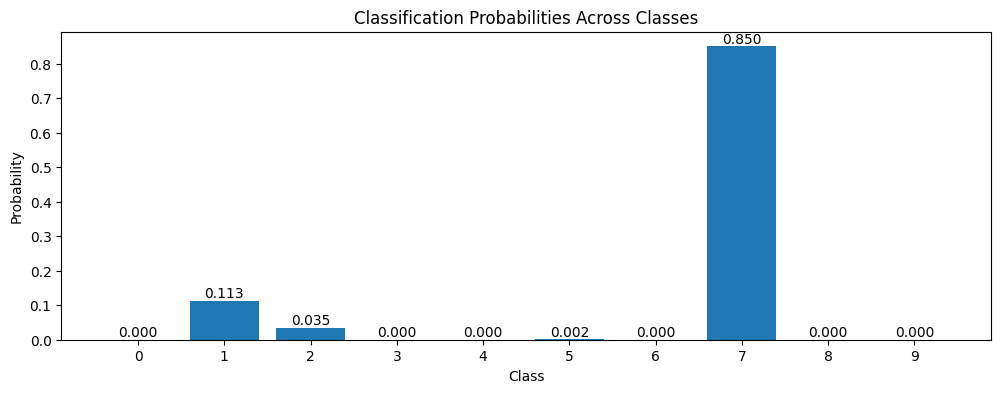

Highest probability: Class 7 (0.850)
Predicted class 7


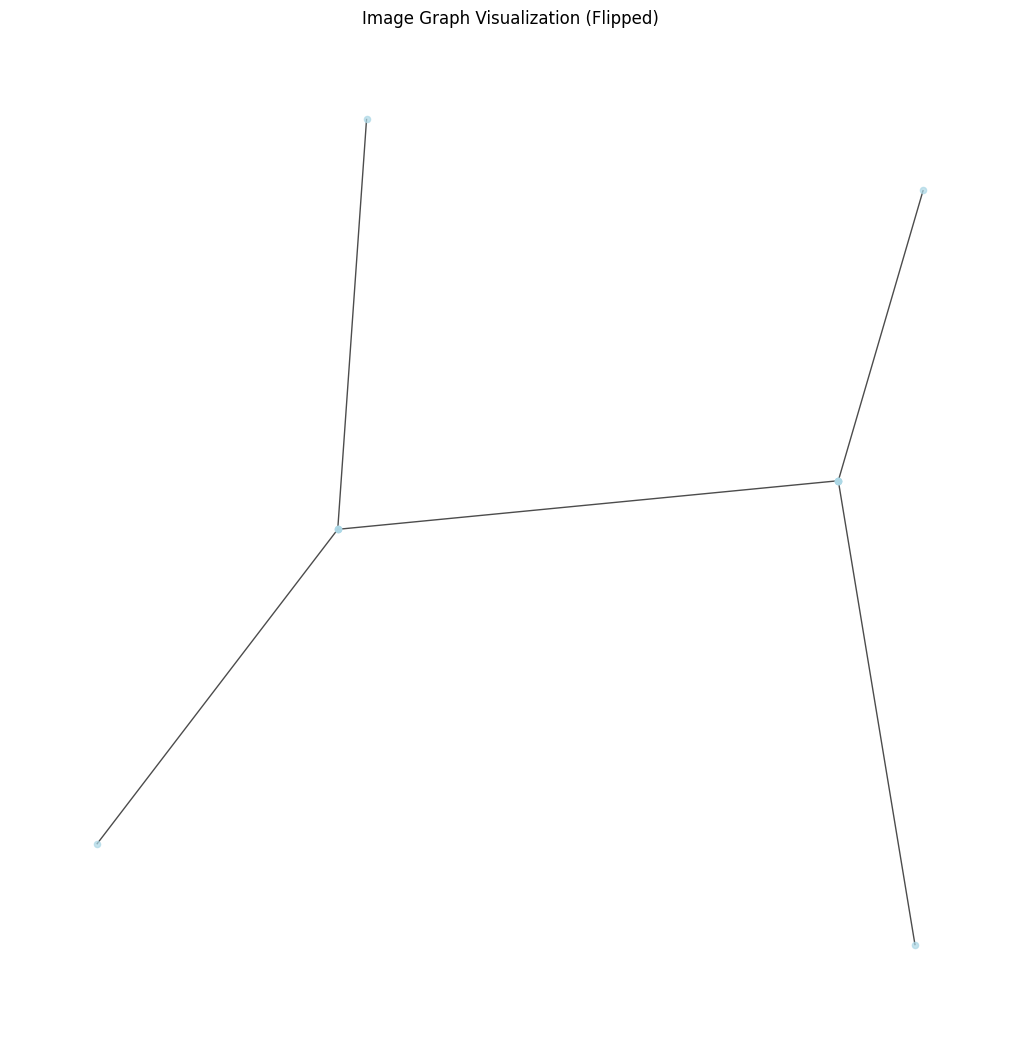

In [236]:
import torch
import torch.nn.functional as F
from torch_geometric.data import Batch

device = torch.device('cpu')
state_dir = torch.load('models/binaries/gat_mnist_20250221_164110.pth')
model = GAT(
    num_of_layers=state_dir["num_of_layers"],
    num_heads_per_layer=state_dir["num_heads_per_layer"],
    num_features_per_layer=state_dir["num_features_per_layer"],
    add_skip_connection=state_dir["add_skip_connection"],
    bias=state_dir["bias"],
    dropout=state_dir["dropout"],
    log_attention_weights=True
).to(device)
print_model_metadata(state_dir)
model.load_state_dict(state_dir['state_dict'], strict=True)
model.eval()

driver = GraphDatabase.driver(uri, auth=(user, password))
with driver.session() as session:
    image_graph = session.execute_read(
        Neo4jToNetworkX.extract_image_graph, image_id_for_test
    )
    
data = MNISTGraphDataset.convert_to_pyg_data(image_graph, 0)
# Add batch vector for single graph
data.batch = torch.zeros(data.num_nodes, dtype=torch.long)
data.to(device=device)

with torch.no_grad():
    logits, _ = model((data.x, data.edge_index))
    graph_logits = global_mean_pool(logits, data.batch)  # Shape [1, 10]
    probabilities = F.softmax(graph_logits, dim=1)
    predicted_class = probabilities.argmax().item()
    # Create bar plot of class probabilities
    probs = probabilities.squeeze().numpy()
    plt.figure(figsize=(12, 4))
    plt.bar(range(10), probs)
    plt.xticks(range(10))
    plt.xlabel('Class')
    plt.ylabel('Probability')
    plt.title('Classification Probabilities Across Classes')
    
    # Add value labels on top of each bar
    for i, prob in enumerate(probs):
        plt.text(i, prob, f'{prob:.3f}', ha='center', va='bottom')
    
    plt.show()
    
    print(f'Highest probability: Class {predicted_class} ({probs[predicted_class]:.3f})')
    print(f'Predicted class {predicted_class}')
    
plt.figure(figsize=(10, 10))
pos = {node: (data.get('x1', data.get('x', 0)), -data.get('y1', data.get('y', 0))) 
       for node, data in image_graph.nodes(data=True)}
nx.draw(image_graph, pos, node_size=20, node_color='lightblue',
        with_labels=False, alpha=0.7)
plt.title("Image Graph Visualization (Flipped)")
plt.show()

In [233]:
# Test graph features
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)
for batch in test_loader:
    print("Test graph features:")
    print(f"Shape: {batch.x.shape}")
    print(f"Mean: {batch.x.mean(dim=0)}")
    print(f"Std: {batch.x.std(dim=0)}")
    break

# Inference graph features
print("Inference graph features:")
print(f"Shape: {data.x.shape}")
print(f"Mean: {data.x.mean(dim=0)}")
print(f"Std: {data.x.std(dim=0)}")

Test graph features:
Shape: torch.Size([15, 34])
Mean: tensor([ 2.8033e+01,  2.5805e+01,  2.5337e+01,  2.4619e+01,  2.2957e+01,
         2.1180e+01,  2.6000e+00,  4.3595e-02, -2.5911e-02,  3.9338e-01,
         5.3333e-01,  4.6667e-01,  0.0000e+00,  0.0000e+00,  6.6667e-02,
         2.0000e-01,  2.6667e-01,  1.8667e-01,  9.0667e+01,  2.1634e+01,
         0.0000e+00,  2.6000e+00,  8.5992e+00,  0.0000e+00,  0.0000e+00,
         1.0000e+00,  2.0000e+00,  0.0000e+00,  4.0000e+00,  2.6667e-01,
         7.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00])
Std: tensor([2.8955e+01, 3.2137e+01, 2.9593e+01, 3.2776e+01, 2.6487e+01, 3.0363e+01,
        1.1832e+00, 2.4007e-01, 5.4105e-01, 1.0374e-01, 5.1640e-01, 5.1640e-01,
        0.0000e+00, 0.0000e+00, 2.5820e-01, 4.1404e-01, 4.5774e-01, 3.5187e-02,
        1.1585e+02, 3.8790e+01, 0.0000e+00, 1.1832e+00, 1.4159e+01, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 4.5774e-01,
        0.0000e+00, 0.0000e+00, 0.0000e+0

/Users/mlapin/anaconda3/envs/natural_agi/lib/python3.11/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [308]:
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True)
for batch in test_loader:
    batch = batch.to(device)
    with torch.no_grad():
        logits, _ = model((batch.x, batch.edge_index))
        average_logits = logits.mean(dim=0)
        predicted_class = average_logits.argmax().item()
        true_class = batch.y.item()
        print(f'Predicted: {predicted_class}, True: {true_class}')
    break  # Test one graph

Predicted: 6, True: 6
